# 🧠 Model Interpretation with SHAP (Explainable AI)

## 🎯 Objective
To interpret the final tuned LightGBM model using SHAP (SHapley Additive exPlanations), providing transparency into how predictions are made at both global and local levels.

---

## 💡 Why This Matters

- Models alone are not enough — we must **explain decisions**
- Critical for:
  - Financial risk modeling
  - Regulatory compliance
  - Trust in ML systems

---

## 🔍 What We Will Do

1. Train final model using tuned parameters
2. Compute SHAP values
3. Analyze:
   - Global feature importance
   - Feature impact direction
   - Individual predictions
4. Extract business insights

---

## 🧠 Expected Outcome

✔ Understand *why* model predicts default  
✔ Identify key drivers of risk  
✔ Translate ML → business insights  
✔ Strengthen portfolio significantly

**1. IMPORTS**

In [1]:
# ======================
# IMPORTS
# ======================
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap
import lightgbm as lgb

from src.pipeline import full_pipeline
from src.data_loader import load_data
from src.config import set_seed

set_seed(42)
shap.initjs()

**2. LOAD DATA**

In [2]:
train, test, _ = load_data()

train_processed, test_processed = full_pipeline(train, test)

print("Train shape:", train_processed.shape)

Train shape: (68654, 26)


**3. FEATURE SET LEAKAGE**

In [3]:
DROP_COLS = [
    "ID",
    "target",
    "customer_id",
    "tbl_loan_id",
    "lender_id",
    "disbursement_date",
    "due_date"
]

FEATURES = [col for col in train_processed.columns if col not in DROP_COLS]

X = train_processed[FEATURES]
y = train_processed["target"]

print("Number of features:", len(FEATURES))

Number of features: 19


**4. CLASS IMBALANCE**

In [4]:
pos = y.sum()
neg = len(y) - pos

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 53.573926868044516


**5. TRAIN FINAL MODEL (TUNED)**

In [5]:
model = lgb.LGBMClassifier(
    n_estimators=935,
    learning_rate=0.103,
    num_leaves=82,
    max_depth=4,
    min_child_samples=85,
    subsample=0.63,
    colsample_bytree=0.97,
    reg_alpha=0.083,
    reg_lambda=0.029,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

model.fit(X, y)

[LightGBM] [Info] Number of positive: 1258, number of negative: 67396
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2253
[LightGBM] [Info] Number of data points in the train set: 68654, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018324 -> initscore=-3.981063
[LightGBM] [Info] Start training from score -3.981063
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,boosting_type,'gbdt'
,num_leaves,82
,max_depth,4
,learning_rate,0.103
,n_estimators,935
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,85


**6. SHAP EXPLAINER**

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

c:\Users\otsyu\anaconda3\envs\Python_environment\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


**7. GLOBAL FEATURE IMPORTANCE**

C:\Users\otsyu\AppData\Local\Temp\ipykernel_14576\3017445420.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


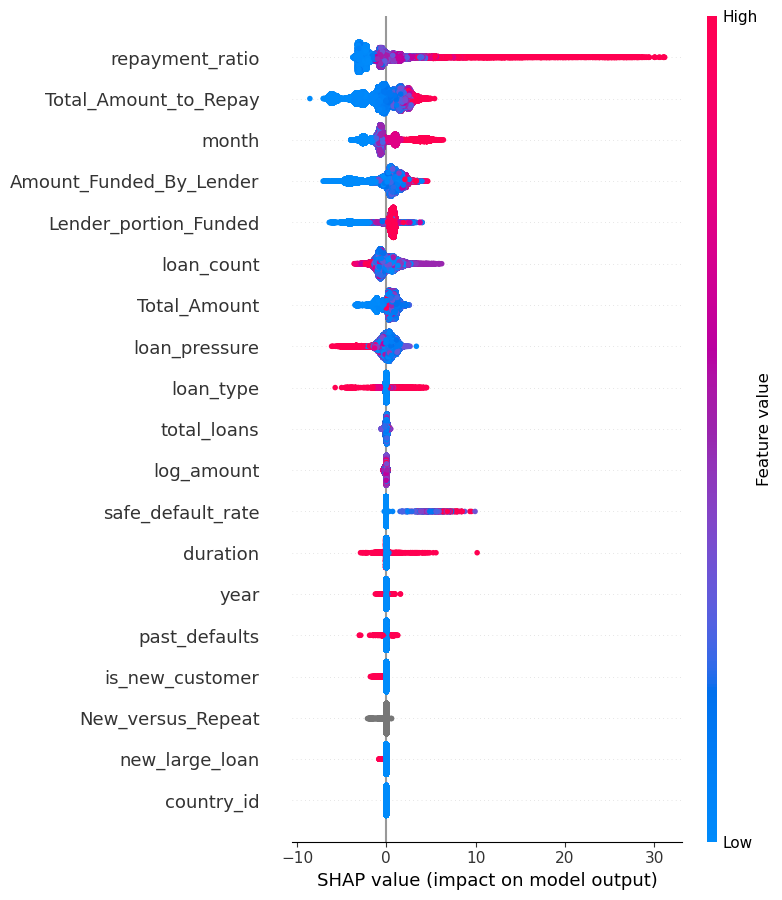

In [7]:
shap.summary_plot(shap_values, X)


---
From the beeswarm plot:

+ Red = high values
+ Blue = low values

---

> 🔴 repayment_ratio
+ High values → strong positive SHAP (increase default risk)
+ Very steep spread → non-linear explosion

👉 Interpretation:

+ There is a critical threshold
+ After that → risk skyrockets

---

>  🔴 Total_Amount_to_Repay
+ Higher → increases risk
+ But weaker than repayment_ratio

👉 Meaning:

+ Absolute value matters
+ But relative burden matters more

---

> 🔴 month

+ Clear pattern → some months increase risk

👉 Interpretation:

+ Seasonality exists
Could be:

+ economic cycles
+ income cycles
+ repayment timing behavior

---

> 🔴 loan_count

+ Mixed effect (both + and -)

👉 Interpretation:

+ Early loans → risk uncertain
+ High loan count:
+ could mean experience (lower risk) OR
+ over-borrowing (higher risk)

✔ This is a non-linear behavioral feature

---

**8. FEATURE SET IMPORTANCE (BAR)**

C:\Users\otsyu\AppData\Local\Temp\ipykernel_14576\1599793300.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type="bar")


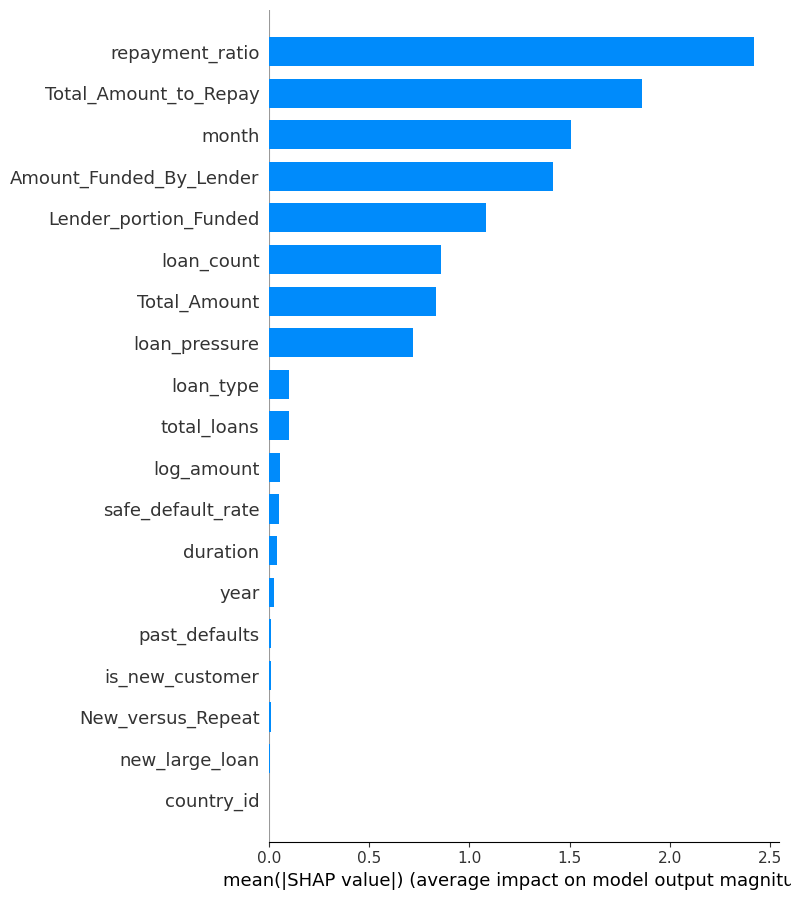

In [8]:
shap.summary_plot(shap_values, X, plot_type="bar")


---

> 🧠 Interpretation

This confirms something very important:

+ The model is primarily driven by financial stress indicators, NOT IDs or leakage

> 🔥 Key Insight

+ repayment_ratio dominates → this is essentially a risk intensity signal
+ The model is saying:

“The higher the repayment burden relative to the loan → the higher the default risk”

+ ✔ This is financially intuitive

+ ✔ This is exactly what banks model

---

**9. FEATURE DEPENDENCE PLOTS**

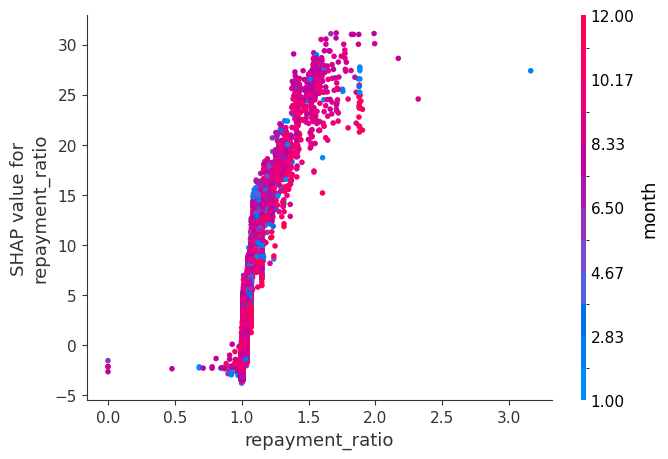

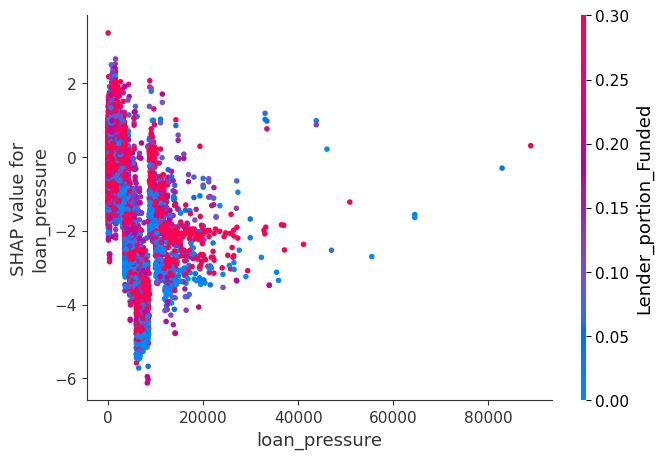

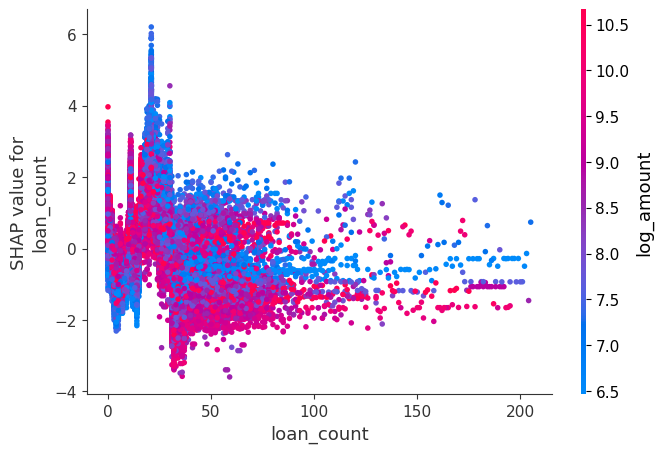

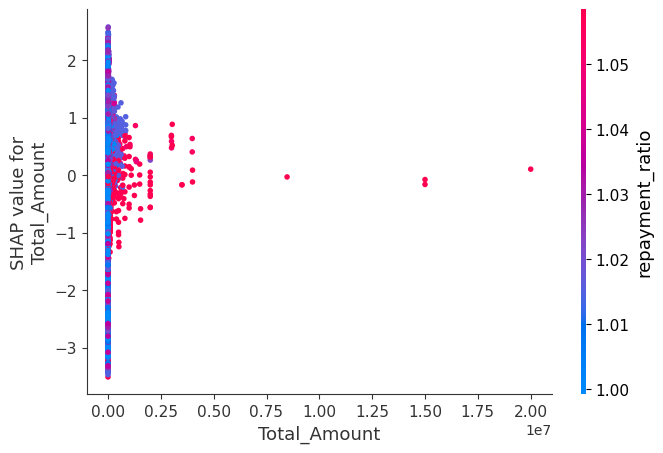

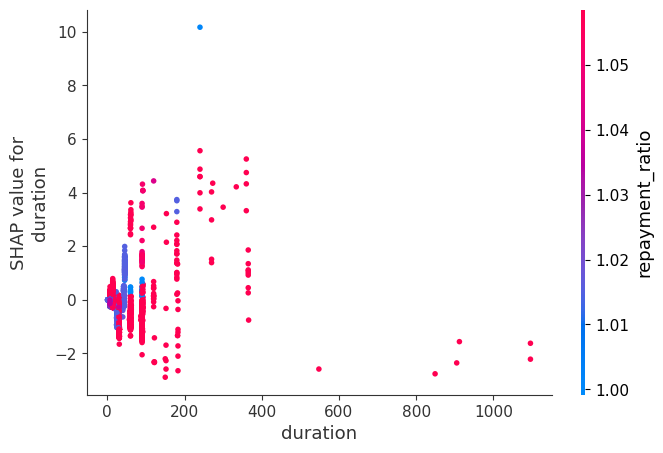

In [9]:
important_features = [
    "repayment_ratio",
    "loan_pressure",
    "loan_count",
    "Total_Amount",
    "duration"
]

for feature in important_features:
    shap.dependence_plot(feature, shap_values, X)

---

> 📈 repayment_ratio (VERY IMPORTANT)

+ Flat around ~1.0
+ Then sharp exponential rise

🧠 Meaning:

+ 🚨 There is a risk threshold
+ Below threshold → safe
+ Above threshold → rapidly increasing default probability

✔ This is exactly how credit risk behaves in real life

---

> 📉 loan_pressure
+ Mostly negative SHAP values
+ Higher values → increase risk (more negative → pushing toward default)

👉 Interpretation:

+ High loan pressure = financial strain

---

> 🔄 loan_count
+ Non-linear curve
+ Initially volatile → stabilizes → then shifts

👉 Interpretation:

+ Behavioral segmentation:
    + New users → unpredictable
    + Experienced users → more stable
    + Very frequent borrowers → risk again increases


+ ✔ This is very advanced signal detection
---

> 📊 Total_Amount

+ Weak effect overall
+ Wide scatter

👉 Interpretation:

+ Loan size alone is NOT predictive

+ ✔ Context (ratio, pressure) matters more than raw value

---

>⏳ duration

+ Mixed effect
+ Some long durations increase risk, others reduce it

👉 Interpretation:

+ Duration interacts with other variables (not standalone)
---

**10. INDIVIDUAL PREDICTION EXPLANATION**

In [10]:
# Example: first prediction
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X.iloc[0]
)


---

> Final prediction: -3.47 (log-odds)

> 🔴 Factors increasing risk:

+ repayment_ratio = +12.53
+ Total_Amount_to_Repay
+ Amount_Funded_By_Lender

> 🔵 Factors reducing risk:
+ loan_type
+ loan_pressure

> 🧠 Interpretation

+ The prediction is a push-pull system:

    ✔ Some features strongly push toward default

    ✔ Others pull back toward safety

👉 Final outcome = balance of forces

---

**11. WATERFALL PLOT**

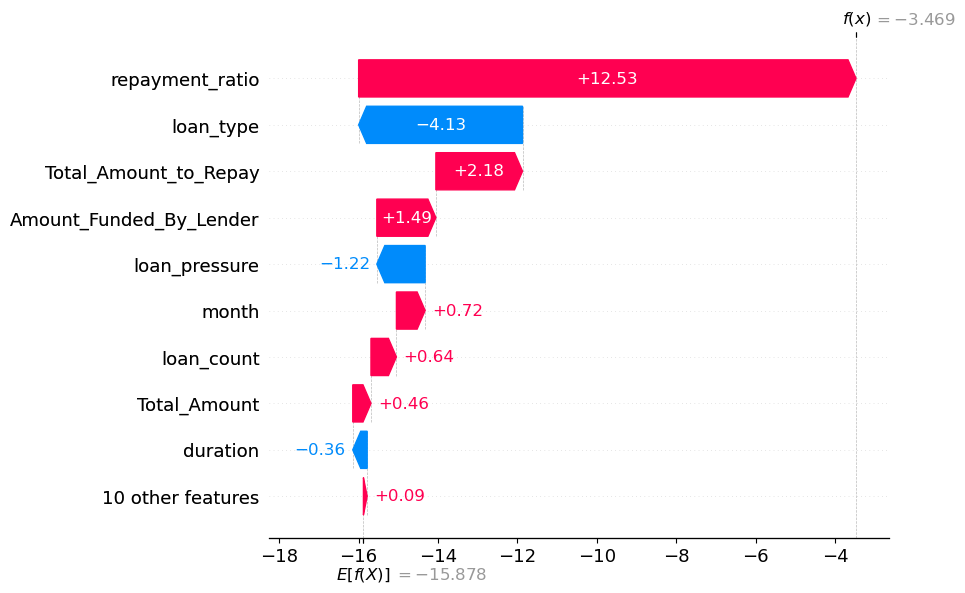

In [11]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    feature_names=FEATURES
)


---
> 🧠 Key Observations:

+ repayment_ratio = dominant driver (+12.53)
+ loan_type = strong negative impact (-4.13)
+ Others contribute marginally

> 🔥 Critical Insight

The model is NOT evenly distributed — it is feature-dominant

✔ One feature (repayment_ratio) carries massive weight

✔ Others fine-tune prediction

---

# 🧠 Model Interpretation Summary (SHAP Analysis)

## 🎯 Objective

To interpret the final LightGBM model using SHAP and understand the key drivers of loan default predictions.

---

## 🔍 Key Findings

### 1. Dominant Risk Driver: Repayment Ratio

The most influential feature is **repayment_ratio**, which exhibits a strong non-linear relationship with the target.

* Higher values significantly increase default risk
* A clear threshold effect is observed, beyond which risk escalates rapidly

👉 This confirms that **relative repayment burden** is the most critical determinant of default.

---

### 2. Financial Stress Indicators Drive the Model

Other top contributing features include:

* Total_Amount_to_Repay
* Amount_Funded_By_Lender
* loan_pressure

These features collectively represent **financial strain and repayment difficulty**, aligning with real-world credit risk principles.

---

### 3. Behavioral Features Provide Additional Signal

Features such as:

* loan_count
* past_defaults

capture borrower behavior and history.

* loan_count shows a non-linear relationship, indicating different risk profiles across borrower segments

---

### 4. Temporal Effects (Seasonality)

The feature **month** demonstrates measurable influence, suggesting:

* Seasonal repayment patterns
* Potential economic or income-cycle effects

---

### 5. Feature Interactions and Non-Linearity

SHAP dependence plots reveal:

* Strong non-linear relationships
* Threshold-based behavior (especially for repayment_ratio)
* Interaction effects between financial and behavioral variables

---

### 6. Individual Prediction Analysis

Local explanations show that predictions are driven by a combination of:

* Strong positive risk contributors (e.g., repayment_ratio)
* Counterbalancing factors (e.g., loan_type, loan_pressure)

👉 The model behaves as a **balanced decision system**, aggregating multiple signals.

---

### 7. Model Validity and Integrity

* No evidence of dominant ID-based or leakage features
* Model relies on **meaningful financial and behavioral signals**
* Feature importance aligns with domain knowledge

---

## ⚠️ Important Consideration

The feature `safe_default_rate` requires further validation to ensure:

* It is strictly computed using past data
* It does not introduce target leakage

---

## 💼 Business Implications

The model identifies key drivers of default risk:

* High repayment burden → increased default likelihood
* Frequent borrowing → behavioral risk signal
* Financial pressure → critical indicator of distress

👉 These insights can support:

* Credit scoring systems
* Risk-based pricing strategies
* Loan approval decisions

---
---

> A model is only valuable if it can be understood, trusted, and acted upon.
